In [46]:
# --- Imports ---
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

from src.data_prep import PrepAndDataLoader
from src.model_wrapper import Model, set_global_seed  # <- zeigt auf die oben gezeigte Datei

In [47]:
# %%
# --- Utils ---
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def plot_history_from_json(history_json_path: str, title: str = ""):
    if not os.path.isfile(history_json_path):
        print(f"[WARN] History file not found: {history_json_path}")
        return
    with open(history_json_path, "r") as f:
        hist = json.load(f)

    plt.figure()
    if "loss" in hist:
        plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"Training History {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [48]:
# %%
# --- Config laden ---
CONFIG = json.load(open("../../config.json"))
set_global_seed(CONFIG["random_seed"])

CSV_PATH = CONFIG["data"]["files"][0]
cols = CONFIG["data"]["columns"]
target_col = CONFIG["data"]["target_col"]

train_split = CONFIG["data"]["training_split"]
val_split = CONFIG["data"]["validation_split"]

WINDOW = int(CONFIG["data"]["window_size"])
H = int(CONFIG["data"]["horizons"][0])
NORMALISE = CONFIG["data"]["normalise"]
NORM_METHOD = CONFIG["data"]["norm_method"]
STRIDE = int(CONFIG["data"].get("stride", 1))

print("Using CSV:", CSV_PATH)
print(f"Window={WINDOW}, Horizon={H}, Norm={NORM_METHOD}, Columns={cols}")




KeyboardInterrupt

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000002AF00F1D6A0>>
Traceback (most recent call last):
  File "C:\Users\juli\anaconda3\envs\BachelorThesis\Lib\site-packages\ipykernel\ipkernel.py", line 796, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
  File "C:\Users\juli\anaconda3\envs\BachelorThesis\Lib\threading.py", line 1479, in enumerate
    def enumerate():
KeyboardInterrupt: 


In [40]:
# %%
# --- Daten vorbereiten ---
dl = PrepAndDataLoader(
    filename=CSV_PATH,
    training_split=train_split,
    validation_split=val_split,
    cols=cols,
    target_col=target_col,
    dtype="float32",
)

# Fenster bauen (paper-konform: Horizon H direkt)
X_tr, y_tr, b_tr, bT_tr = dl.get_train_data(
    normalise=NORMALISE,
    window_size=WINDOW,
    prediction_range=H,
    norm_method=NORM_METHOD,
    stride=STRIDE,

)
X_va, y_va, b_va, bT_va = dl.get_validation_data(
    normalise=NORMALISE,
    window_size=WINDOW,
    prediction_range=H,
    norm_method=NORM_METHOD,
    stride=STRIDE,
)
X_te, y_te, b_te, bT_te = dl.get_test_data(
    normalise=NORMALISE,
    window_size=WINDOW,
    prediction_range=H,
    norm_method=NORM_METHOD,
    stride=STRIDE,
)

dates_te = dl.get_prediction_dates(
    "test",
    window_size=WINDOW,
    prediction_range=H,
    stride=STRIDE,
)  # [N, H] of datetime-like values

print("Shapes ->",
      "X_train", X_tr.shape, "y_train", y_tr.shape,
      "| X_val", X_va.shape, "y_val", y_va.shape,
      "| X_test", X_te.shape, "y_test", y_te.shape)


Shapes -> X_train (2276, 60, 5) y_train (2276, 1, 1) | X_val (718, 60, 5) y_val (718, 1, 1) | X_test (720, 60, 5) y_test (720, 1, 1)


In [41]:
xlstm_cfg = {
    "window_size": CONFIG["data"]["window_size"],
    "n_features": len(CONFIG["data"]["columns"]),
    "horizon": H,
    "units": 128,
    "xlstm_num_blocks": 6,
    "xlstm_slstm_at": [],  #[[], [0], [1], [2], [3], [0,1], [1,2], [2,3]]
    "dropout": 0.1,
    "optimizer": "adamW",
    "learning_rate": 0.001740838159258218,
    "loss": CONFIG["data"]["loss"],

    "xlstm_mlstm_conv1d_kernel_size": 3,
    "xlstm_mlstm_qkv_proj_blocksize": 4,
    "xlstm_mlstm_num_heads": 2,
    "xlstm_mlstm_proj_factor": 1.5,

    "xlstm_slstm_conv1d_kernel": 3,
    "xlstm_slstm_num_heads": 2
}

model = Model()
model.build(
    config=xlstm_cfg,
    model_type="xLSTM",
)
print(f"[Device] Using device: {model.device}")


[Model] xLSTM compiled:
  Input: seq_len=60, features=5 | hidden=128 | horizon=1
  xLSTM blocks=6, sLSTM at=[]
  Trainable params: 485,273
[Device] Using device: cuda


In [42]:
# --- Training ---
train_cfg = CONFIG["training"]
save_dir = CONFIG["xLSTM_model"]["save_dir"]
ensure_dir(save_dir)

ckpt_path = model.train(
    X_tr, y_tr,
    X_va, y_va,
    epochs=int(train_cfg["epochs"]),
    batch_size=int(train_cfg["batch_size"]),
    save_dir=save_dir,
    patience=int(train_cfg["patience"]),
    monitor="val_loss",
    verbose=int(train_cfg["verbose"]),
    restore_best_weights=True,
)
print("Best checkpoint:", ckpt_path)


[Model] Training start | epochs=100 | batch_size=128 | horizon=1
Epoch 001/100 - loss=0.396750 - val_loss=0.040301
[Checkpoint] Saved best model to: ./xlstm_checkpoints\xLSTM_H1_20251127-102902_b128_un128_layx_e100.pt (val_loss=0.040301)
Epoch 002/100 - loss=0.028182 - val_loss=0.020613
[Checkpoint] Saved best model to: ./xlstm_checkpoints\xLSTM_H1_20251127-102902_b128_un128_layx_e100.pt (val_loss=0.020613)
Epoch 003/100 - loss=0.017508 - val_loss=0.025100
Epoch 004/100 - loss=0.014897 - val_loss=0.019765
[Checkpoint] Saved best model to: ./xlstm_checkpoints\xLSTM_H1_20251127-102902_b128_un128_layx_e100.pt (val_loss=0.019765)
Epoch 005/100 - loss=0.012428 - val_loss=0.015395
[Checkpoint] Saved best model to: ./xlstm_checkpoints\xLSTM_H1_20251127-102902_b128_un128_layx_e100.pt (val_loss=0.015395)
Epoch 006/100 - loss=0.009794 - val_loss=0.010308
[Checkpoint] Saved best model to: ./xlstm_checkpoints\xLSTM_H1_20251127-102902_b128_un128_layx_e100.pt (val_loss=0.010308)
Epoch 007/100 - loss

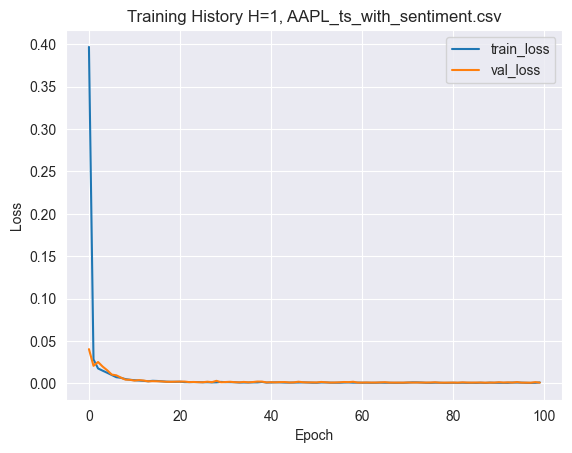

In [43]:
# --- History plot ---
history_json = ckpt_path.replace(".pt", "_history.json")
plot_history_from_json(history_json, title=f"H={H}, {os.path.basename(CSV_PATH)}")


In [44]:
# --- Test evaluation: RMSE & R² (scaled + denorm) ---

yhat_scaled = model.predict_multi_horizon(
    X_te,
    batch_size=int(train_cfg["batch_size"]),
    verbose=0,
)  # [N, H]

ytrue_scaled = y_te.squeeze(-1)    # [N, H]

rmse_scaled = root_mean_squared_error(ytrue_scaled, yhat_scaled)
r2_scaled   = r2_score(ytrue_scaled, yhat_scaled)

print(f"[TEST - SCALED] RMSE={rmse_scaled:.6f} | R2={r2_scaled:.6f}")


if NORMALISE:

    yhat_scaled_3d = yhat_scaled[..., None]  # [N, H, 1]
    ytrue_scaled_3d = y_te                   # [N, H, 1]

    if NORM_METHOD == "percentage":
        yhat_level = dl.denormalise(
            yhat_scaled_3d,
            method="percentage",
            base_values=bT_te,   # [N, 1]
            normalise=True,
        ).squeeze(-1)            # [N, H]

        ytrue_level = dl.denormalise(
            ytrue_scaled_3d,
            method="percentage",
            base_values=bT_te,
            normalise=True,
        ).squeeze(-1)

    elif NORM_METHOD == "minmax":
        yhat_level = dl.denormalise(
            yhat_scaled_3d,
            method="minmax",
            base_values=None,
            normalise=True,
        ).squeeze(-1)

        ytrue_level = dl.denormalise(
            ytrue_scaled_3d,
            method="minmax",
            base_values=None,
            normalise=True,
        ).squeeze(-1)

    else:
        raise ValueError(f"Unknown normalization method: {NORM_METHOD}")

    rmse_level = root_mean_squared_error(ytrue_level, yhat_level)
    r2_level   = r2_score(ytrue_level, yhat_level)

    print(f"[TEST - LEVEL] RMSE={rmse_level:.6f} | R2={r2_level:.6f}")

else:
    yhat_level  = yhat_scaled
    ytrue_level = ytrue_scaled

    print("[TEST] NORMALISE=False → scaled values are already in original scale.")

[TEST - SCALED] RMSE=0.019577 | R2=0.974386
[TEST - LEVEL] RMSE=3.307589 | R2=0.988887


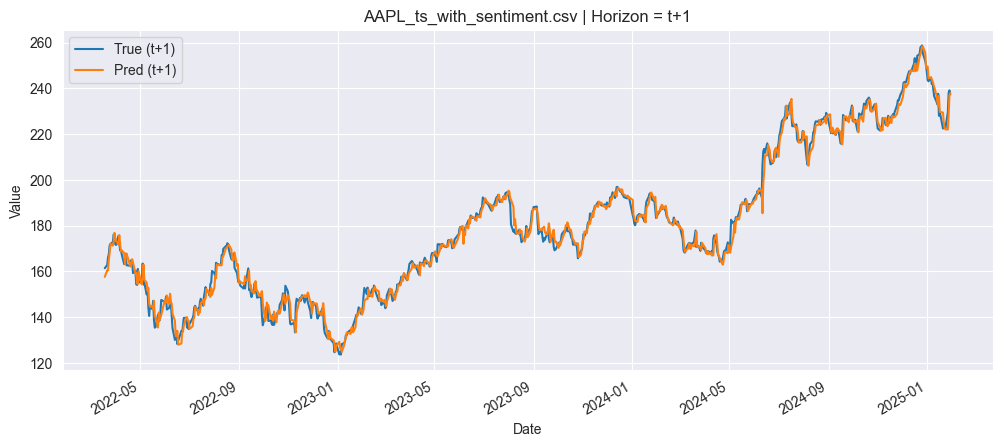

In [45]:
if STRIDE == 1:
    # ---------------------------------------------------------
    # Mode 1: stride=1 → show only last horizon t+H
    # ---------------------------------------------------------
    h_idx = H - 1  # last horizon index (t+H)

    dates_h = dates_te[:, h_idx]    # [N]
    true_h  = ytrue_level[:, h_idx] # [N]
    pred_h  = yhat_level[:, h_idx]  # [N]

    plt.figure(figsize=(12, 5))
    plt.plot(dates_h, true_h,  label=f"True (t+{H})")
    plt.plot(dates_h, pred_h, label=f"Pred (t+{H})")

    plt.title(f"{os.path.basename(CSV_PATH)} | Horizon = t+{H}")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()

else:
    # ---------------------------------------------------------
    # Mode 2: stride > 1 → merge ALL horizons into one time series.
    # Example: H=15, stride=15: all t+1..t+15 become a single smooth line.
    # ---------------------------------------------------------
    dates_flat = dates_te.reshape(-1)
    true_flat  = ytrue_level.reshape(-1)
    pred_flat  = yhat_level.reshape(-1)

    df_plot = pd.DataFrame({
        "date": dates_flat,
        "true": true_flat,
        "pred": pred_flat,
    })

    # Average duplicate dates, sort chronologically
    df_plot = df_plot.groupby("date", as_index=True).mean().sort_index()

    plt.figure(figsize=(12, 5))
    plt.plot(df_plot.index, df_plot["true"], label="True (merged horizons)")
    plt.plot(df_plot.index, df_plot["pred"], label="Pred (merged horizons)")

    plt.title(f"{os.path.basename(CSV_PATH)} | H={H}, stride={STRIDE} (merged series)")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()